# MediQAL — Analyse Exploratoire (EDA)

## Synthèse & Observations

### Structure du dataset
- **Langue :** Français | **Source :** projet ANR MALADES (`ANR-MALADES/MediQAl` sur HuggingFace)
- 3 sous-ensembles : `MCQU` (réponse unique), `MCQM` (réponses multiples), `OEQ` (réponse ouverte)
- **Seul MCQU est retenu** pour le SFT → correspondance univoque question/réponse garantie
- Splits MCQU : `train` (10 113) / `validation` (2 561) / `test` (4 343) → **17 017 lignes** fusionnées
- Colonnes : `id`, `clinical_case`, `question`, `answer_a→e`, `correct_answers` (lettre A-E), `task`, `medical_subject`, `question_type`

### Points d'attention
- ~61 % des lignes ont `clinical_case = NaN` dans le split train (6 178/10 113)
- `correct_answers` est une **lettre** (A/B/C/D/E), pas un entier → mapping différent de FrenchMedMCQA
- Certaines propositions de réponse contiennent des combinaisons indicées (`1+2+3`, `1+3+5`...) → inintelligibles pour un agent de triage
- Questions contenant `(cochez la réponse juste)` → artefact hérité du format QCM papier, sans valeur sémantique
- Questions `cochez la réponse fausse` → la "bonne" réponse dans le dataset est médicalement **fausse** → risque pour la fiabilité du modèle
- Distribution de `correct_answers` déséquilibrée : C (2720) > D (2409) > B (2032) > E (1701) > A (1251)
- MCQM non retenu : `correct_answers` combinées (ex. `A,C,D`) → signal d'apprentissage ambigu
- OEQ non retenu dans cette itération : réponses libres, format plus complexe

### Décisions de nettoyage → `src/processing/mediqal_cleaning.py`
- Fusionner les 3 splits avant traitement (re-découpage stratifié ultérieur)
- Supprimer les colonnes : `id`, `task`, `medical_subject`, `question_type`
- Résoudre `correct_answers` (A-E → nom de colonne) + lookup dynamique pour créer la colonne `answer`
- **Concaténer** `clinical_case` + `question` → champ `question` enrichi (contexte patient + interrogation)
- Supprimer les mentions `(cochez la réponse juste)` dans les questions
- Filtrer les lignes avec `cochez la réponse fausse`
- Filtrer les paires (propositions numérotées dans la question + réponse sous forme d'indices)
- Normaliser en minuscules | Ajouter `dataset_name = "mediqal"`

---
## 1. Chargement des données

In [1]:
from datasets import load_from_disk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\Fabien\Desktop\OC\P14\FINE-TUNING_MEDICAL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mcqm_datasets = load_from_disk("gs://p14-medical-data/raw_data/mediqal_datasets/mcqm_medical/")
mcqu_datasets = load_from_disk("gs://p14-medical-data/raw_data/mediqal_datasets/mcqu_medical/")
oeq_datasets  = load_from_disk("gs://p14-medical-data/raw_data/mediqal_datasets/oeq_medical/")

## 2. Vue d'ensemble des 3 sous-ensembles

In [3]:
for name, ds in [("MCQU", mcqu_datasets), ("MCQM", mcqm_datasets), ("OEQ", oeq_datasets)]:
    total = sum(ds[split].num_rows for split in ds)
    splits = {split: ds[split].num_rows for split in ds}
    print(f"{name} — Total : {total} | Splits : {splits}")

MCQU — Total : 17017 | Splits : {'train': 10113, 'validation': 2561, 'test': 4343}
MCQM — Total : 10617 | Splits : {'train': 5767, 'validation': 1466, 'test': 3384}
OEQ — Total : 4969 | Splits : {'test': 4969}


---
## 3. Exploration MCQU (dataset retenu pour le SFT)

In [4]:
df_mcqu = pd.DataFrame(mcqu_datasets["train"])
print(f"Shape : {df_mcqu.shape}")
print(f"Colonnes : {list(df_mcqu.columns)}")
df_mcqu.head(3)

Shape : (10113, 12)
Colonnes : ['id', 'clinical_case', 'question', 'answer_a', 'answer_b', 'answer_c', 'answer_d', 'answer_e', 'correct_answers', 'task', 'medical_subject', 'question_type']


,id,clinical_case,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,task,medical_subject,question_type
0,7543,"Monsieur R. âgé de 37 ans, forestier de son mé...",Au sujet des vaccinations :,Le vaccin contre la fièvre jaune est obligatoire,Le vaccin contre la fièvre jaune peut se faire...,Le vaccin contre le choléra est un vaccin qui ...,Le vaccin contre l'hépatite B est conseillé ma...,Les vaccinations contre le tétanos et la polio...,A,QCU,Infectious Diseases,Understanding
1,10495,NaN,"Devant une tuméfaction cervicale médiane, juxt...",Kyste dermoïde,Laryngocèle,Kyste du tractus thyréoglosse,Grenouillette sublinguale,Lithiase salivaire,C,QCU,Otorhinolaryngology (ENT),Understanding
2,17342,Une jeune femme de 24 ans vous consulte pour a...,Le traitement de cette patiente fait appel à :,Chirurgie en urgence,Iode radio-actif en urgence,Iode radio-actif en préparation à la chirurgie,Administration d'antithyroïdiens,Aucun de ces traitements,D,QCU,Endocrinology and Metabolism,Reasoning


In [5]:
df_mcqu.describe(include="all")

,id,clinical_case,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,task,medical_subject,question_type
count,10113,3935,10113,10113,10113,10113,10113,10113,10113,10113,10113,10113
unique,10113,1697,9697,7800,7953,8002,8025,7746,5,1,33,2
top,7543,"Une patiente âgée de 34 ans, célibataire, est ...",Quel est le diagnostic le plus probable ?,1+2+3,1+3,2+4,4,1+2+3+4,C,QCU,Cardiology,Understanding
freq,1,13,20,397,304,282,257,258,2720,10113,691,6933


In [6]:
df_mcqu.isna().sum()

id                    0
clinical_case      6178
question              0
answer_a              0
answer_b              0
answer_c              0
answer_d              0
answer_e              0
correct_answers       0
task                  0
medical_subject       0
question_type         0
dtype: int64

### 3.1 Doublons

In [7]:
print(f"Doublons exacts : {df_mcqu.duplicated().sum()}")
df_mcqu[df_mcqu.duplicated(keep=False)]

Doublons exacts : 0


,id,clinical_case,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,task,medical_subject,question_type


### 3.2 Distribution des réponses correctes

In [8]:
df_mcqu["correct_answers"].value_counts()

correct_answers
C    2720
D    2409
B    2032
E    1701
A    1251
Name: count, dtype: int64

In [9]:
# Distribution par spécialité médicale
df_mcqu["medical_subject"].value_counts().head(15)

medical_subject
Cardiology                      691
Hepato-Gastroenterology         661
Gynecology and Obstetrics       626
Endocrinology and Metabolism    552
Pulmonology                     535
Hematology                      525
Nephro-Urology                  496
Pediatrics                      467
Psychiatry                      419
Rheumatology                    394
Neurology                       394
Infectious Diseases             390
Otorhinolaryngology (ENT)       333
Orthopedics                     323
Pathological Anatomy            308
Name: count, dtype: int64

### 3.3 Analyse du champ `clinical_case`

clinical_case manquant : 6178/10113 (61.1%)


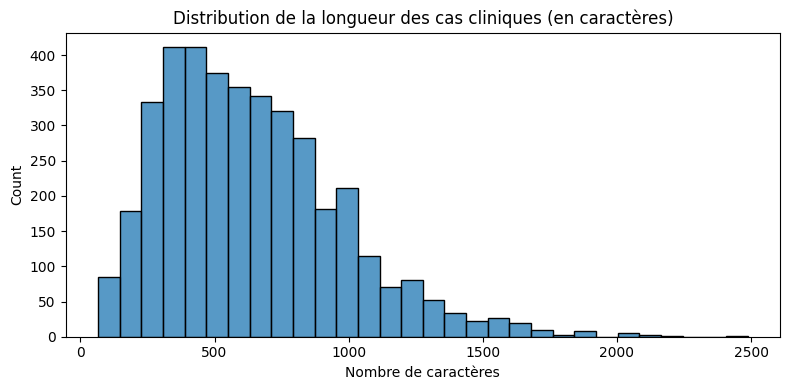

In [10]:
n_missing = df_mcqu["clinical_case"].isna().sum()
n_total = len(df_mcqu)
print(f"clinical_case manquant : {n_missing}/{n_total} ({n_missing/n_total:.1%})")

# Distribution des longueurs (lignes avec cas clinique uniquement)
len_clinical_cases = df_mcqu.loc[df_mcqu["clinical_case"].notna(), "clinical_case"].str.len()
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(len_clinical_cases, bins=30, ax=ax)
ax.set_title("Distribution de la longueur des cas cliniques (en caractères)")
ax.set_xlabel("Nombre de caractères")
plt.tight_layout()
plt.show()

### 3.4 Identification des patterns problématiques

In [11]:
# Questions à négation : la réponse "correcte" est médicalement fausse
mask_false = df_mcqu["question"].str.contains("cochez la réponse fausse", case=False)
print(f"Questions à négation : {mask_false.sum()}")
df_mcqu[mask_false][["question", "correct_answers"]].head(3)

Questions à négation : 468


,question,correct_answers
14,(cochez la réponse fausse) Le syndrome de Wida...,D
30,(cochez la réponse fausse) Au cours de l'Infec...,B
56,(cochez la réponse fausse) La structure des HD...,D


In [12]:
# Artefacts QCM papier : "(cochez la réponse juste)"
mask_coche = df_mcqu["question"].str.contains(r"\(cochez la réponse juste\)", case=False)
print(f"Questions avec artefact '(cochez la réponse juste)' : {mask_coche.sum()}")
df_mcqu[mask_coche]["question"].head(3)

Questions avec artefact '(cochez la réponse juste)' : 1759


7     (cochez la réponse juste) Cette fracture conso...
8     (cochez la réponse juste) La réaction neuro-ho...
28    (cochez la réponse juste) Parmi les complicati...
Name: question, dtype: str

In [13]:
# Réponses indicées (ex: "1+2+3") dans les colonnes de propositions
answer_cols = ["answer_a", "answer_b", "answer_c", "answer_d", "answer_e"]
indexed_mask = df_mcqu[answer_cols].apply(
    lambda col: col.str.contains(r"^\s*\d+(\s*[+\s]\s*\d+)+\s*$", na=False, regex=True)
).any(axis=1)
print(f"Lignes avec réponses indicées dans les propositions : {indexed_mask.sum()}")
df_mcqu[indexed_mask][["question", "correct_answers", "answer_a", "answer_b"]].head(3)

Lignes avec réponses indicées dans les propositions : 860


C:\Users\Fabien\AppData\Local\Temp\ipykernel_26928\2095117197.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  lambda col: col.str.contains(r"^\s*\d+(\s*[+\s]\s*\d+)+\s*$", na=False, regex=True)


,question,correct_answers,answer_a,answer_b
22,Le syndrome des anti-phospholipides au cours d...,E,1+2,2+3
28,(cochez la réponse juste) Parmi les complicati...,C,1+2+3,4+5+6
62,En cas de piqûre accidentelle d'une infirmière...,D,2+3+5,1+2+3


---
## 4. Exploration MCQM (non retenu — réponses multiples)

In [14]:
df_mcqm = pd.DataFrame(mcqm_datasets["train"])
print(f"Shape : {df_mcqm.shape}")
# Exemples de correct_answers combinées → signal d'apprentissage ambigu pour le SFT
print("\nExemples de correct_answers (combinaisons) :")
print(df_mcqm["correct_answers"].value_counts().head(10))
df_mcqm.head(3)

Shape : (5767, 12)

Exemples de correct_answers (combinaisons) :
correct_answers
A,B,C        351
A,B,C,D,E    325
A,B,C,D      300
A,B,C,E      288
B,D          266
A,C,D        260
A,C,E        250
B,C          247
A,B,D        238
A,B,D,E      235
Name: count, dtype: int64


,id,clinical_case,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,task,medical_subject,question_type
0,11399,Plusieurs jours après un contage avec un enfan...,Quelle(s) proposition(s) peut (peuvent) s'appl...,Transmission manuportée,La phase de contagiosité dure 8 jours,Maladie strictement humaine,Confère une immunité,Transmission indirecte possible,"C,D",QCM,Infectious Diseases,Understanding
1,17928,NaN,Quel(s) germe(s) est (sont) responsable(s) de ...,Gardnerella Vaginalis,Trichomonas,Tréponèmes,Candida albicans,Strepto B,"A,B",QCM,Gynecology and Obstetrics,Understanding
2,17520,"Une jeune femme de 26 ans, d'origine française...","En cours d'hospitalisation, laquelle ou lesque...",Réduction de l'apport en protéines animales,Association d'une sulfonylurée à l'insuline,Conservation du même type d'insuline mais augm...,Education à l'autosurveillance glycémique,"Adaptation d'un nouveau schéma thérapeutique, ...","A,D,E",QCM,Endocrinology and Metabolism,Reasoning


---
## 5. Exploration OEQ (non retenu — réponse ouverte)

In [17]:
df_oeq = pd.DataFrame(oeq_datasets["test"])
print(f"Shape : {df_oeq.shape}")
print(f"Colonnes : {list(df_oeq.columns)}")
df_oeq.head(3)

Shape : (4969, 7)
Colonnes : ['id', 'clinical_case', 'cc_question_number', 'question', 'answer', 'medical_subject', 'question_type']


,id,clinical_case,cc_question_number,question,answer,medical_subject,question_type
0,1,"Homme, 58 ans, majoration de dyspnée chez un B...",1,Quels sont éléments de gravité au moment de l’...,"FC>125bpm\n Terrain : ATCD de BPCO, insuffisan...",Emergency Medicine,Reasoning
1,2,"Homme, 58 ans, majoration de dyspnée chez un B...",2,Caractérisez en une phrase le tableau syndrom...,Insuffisance respiratoire aiguë / exacerbation...,Emergency Medicine,Reasoning
2,3,"Homme, 58 ans, majoration de dyspnée chez un B...",3,Quelle est l'explication la plus probable de l...,"Signes d’hypercapnie, pas d’effet du traitemen...",Emergency Medicine,Reasoning
